<a href="https://colab.research.google.com/github/Jalilelibrahimi/A-deep-learning-based-model-for-brain-tumors-detection/blob/main/VGG16_Neutrosophic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D,Dropout,BatchNormalization, Activation # Import Activation here
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential # Import Sequential here
from tensorflow.keras.optimizers import Adam
from PIL import Image
from tensorflow.keras.callbacks import EarlyStopping
import cv2
from google.colab.patches import cv2_imshow # Import cv2_imshow
from tqdm import tqdm
import itertools
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
import shutil
RANDOM_SEED = 123
print("All modules have been imported")

All modules have been imported


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abhranta_brain_tumor_detection_mri_path = kagglehub.dataset_download('abhranta/brain-tumor-detection-mri')

print('Data source import complete.')


Data source import complete.


In [ ]:
from IPython.display import clear_output
# !pip install imutils
clear_output()

#Data

In [ ]:
!apt-get install tree
clear_output()
# create new folders
# !mkdir TRAIN TEST VAL TRAIN/YES TRAIN/NO TEST/YES TEST/NO VAL/YES VAL/NO
!mkdir TRAIN TEST TRAIN/YES TRAIN/NO TEST/YES TEST/NO

!tree -d

mkdir: cannot create directory ‘TRAIN’: File exists
mkdir: cannot create directory ‘TEST’: File exists
mkdir: cannot create directory ‘TRAIN/YES’: File exists
mkdir: cannot create directory ‘TRAIN/NO’: File exists
mkdir: cannot create directory ‘TEST/YES’: File exists
mkdir: cannot create directory ‘TEST/NO’: File exists
.
├── sample_data
├── TEST
│   ├── NO
│   └── YES
└── TRAIN
    ├── NO
    └── YES

7 directories


In [ ]:
IMG_PATH = '/root/.cache/kagglehub/datasets/abhranta/brain-tumor-detection-mri/versions/1/Brain_Tumor_Detection'

In [ ]:
# import os
# import shutil
# import cv2
# import numpy as np


# def calc_I(data, p=3, q=3):
#     kernel = np.ones((p, p), np.float32) / q
#     dataMean = cv2.filter2D(data, -1, kernel)
#     deltaMean = np.abs(data - dataMean)
#     deltaMin = np.min(deltaMean)
#     deltaMax = np.max(deltaMean)
#     I = (deltaMean - deltaMin) / (deltaMax - deltaMin)
#     return I

# def Neutrosophic(img, p=3, m=5):
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     gMean = cv2.blur(img, (p, p))
#     gMin = np.min(gMean)
#     gMax = np.max(gMean)
#     T = (gMean - gMin) / (gMax - gMin)
#     I = 1- calc_I(img)
#     F = 1 - T
#     return T*255,I*255,F*255

# def combine_to_rgb(T, I, F):
#     T = cv2.normalize(T, None, 0, 1, cv2.NORM_MINMAX)
#     I = cv2.normalize(I, None, 0, 1, cv2.NORM_MINMAX)
#     F = cv2.normalize(F, None, 0, 1, cv2.NORM_MINMAX)
#     T_8bit = (T * 255).astype(np.uint8)
#     I_8bit = (I * 255).astype(np.uint8)
#     F_8bit = (F * 255).astype(np.uint8)
#     rgb_image = cv2.merge((F_8bit, I_8bit, T_8bit))
#     return rgb_image

In [ ]:
import os
import shutil
import cv2
import numpy as np


def calc_I(data, p=3, q=3):
    kernel = np.ones((p, p), np.float32) / q
    dataMean = cv2.filter2D(data, -1, kernel)
    deltaMean = np.abs(data - dataMean)
    deltaMin = np.min(deltaMean)
    deltaMax = np.max(deltaMean)
    I = (deltaMean - deltaMin) / (deltaMax - deltaMin)
    return I

def Neutrosophic(img, p=3, m=5):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gMean = cv2.blur(img, (p, p))
    gMin = np.min(gMean)
    gMax = np.max(gMean)
    T = (gMean - gMin) / (gMax - gMin)
    I = 1- calc_I(img)
    F = 1 - T
    return T*255,I*255,F*255

def combine_to_rgb(T, I, F):
    T = cv2.normalize(T, None, 0, 1, cv2.NORM_MINMAX)
    I = cv2.normalize(I, None, 0, 1, cv2.NORM_MINMAX)
    F = cv2.normalize(F, None, 0, 1, cv2.NORM_MINMAX)
    T_8bit = (T * 255).astype(np.uint8)
    I_8bit = (I * 255).astype(np.uint8)
    F_8bit = (F * 255).astype(np.uint8)
    rgb_image = cv2.merge((F_8bit, I_8bit, T_8bit))
    return rgb_image

# ... (rest of your code) ...

# split the data by train/val/test
for CLASS in os.listdir(IMG_PATH):
    if CLASS=="yes" or CLASS== 'no':
        if not CLASS.startswith('.'):
            IMG_NUM = len(os.listdir(IMG_PATH +"/"+ CLASS))
            for (n, FILE_NAME) in enumerate(os.listdir(IMG_PATH +"/"+ CLASS)):
                img_path = IMG_PATH+ '/' +  CLASS + '/' + FILE_NAME  # Store the image path

                # Load the image using cv2.imread
                img = cv2.imread(img_path)

                t,i,f = Neutrosophic(img) # Now pass the loaded image
                # img = combine_to_rgb(t,t,t)
                # img = combine_to_rgb(i,i,i)
                img = combine_to_rgb(f,f,f)

                # Use img_path instead of img for shutil.copy
                # and save the processed image to the new path

                dest_path = os.path.join('/content/TEST/' + CLASS.upper() + '/' + FILE_NAME)

                if n < 0.3*IMG_NUM:
                    cv2.imwrite(dest_path, img) # Save the processed image
                    #shutil.copy(img_path, dest_path)
                else:
                    dest_path = os.path.join('/content/TRAIN/'+ CLASS.upper() + '/' + FILE_NAME)
                    cv2.imwrite(dest_path, img)
                    #shutil.copy(img_path, dest_path)
                # else:
                #     dest_path = os.path.join('/content/VAL/'+ CLASS.upper() + '/' + FILE_NAME)
                #     cv2.imwrite(dest_path, img)
                #     #shutil.copy(

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator




def load_data(dir_path, img_size=(100,100)):
    """
    Load resized images as np.arrays to workspace
    """
    X = []
    y = []
    i = 0
    # Use a different variable name to avoid conflict
    image_labels = dict()
    for path in tqdm(sorted(os.listdir(dir_path))):
        if not path.startswith('.'):
            image_labels[i] = path  # Use image_labels instead of labels
            for file in os.listdir(dir_path + path):
                if not file.startswith('.'):
                    img = cv2.imread(dir_path + path + '/' + file)
                    # t,i_img,f = Neutrosophic(img) # Now pass the loaded image
                    # img = combine_to_rgb(t,i_img,t)
                    img = cv2.resize(img, img_size)
                    X.append(img)
                    y.append(i)
        i += 1
    X = np.array(X)
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X, y, image_labels # Return image_labels instead of labels

In [ ]:
TRAIN_DIR = '/content/TRAIN/'
TEST_DIR = '/content/TEST/'
# VAL_DIR = '/content/VAL/'
IMG_SIZE = (224,224)

In [ ]:
# # TRAIN_DIR = 'TRAIN_CROP/'
# # VAL_DIR = 'VAL_CROP/'
# RANDOM_SEED = 42
# train_datagen = ImageDataGenerator(
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     shear_range=0.1,
#     brightness_range=[0.5, 1.5],
#     horizontal_flip=True,
#     vertical_flip=True,
#     preprocessing_function=preprocess_input
# )

# test_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input
# )


# train_generator = train_datagen.flow_from_directory(
#     TRAIN_DIR,
#     color_mode='rgb',
#     target_size=IMG_SIZE,
#     batch_size=32,
#     class_mode='binary',
#     seed=RANDOM_SEED
# )


# validation_generator = test_datagen.flow_from_directory(
#     VAL_DIR,
#     color_mode='rgb',
#     target_size=IMG_SIZE,
#     batch_size=10,
#     class_mode='binary',
#     seed=RANDOM_SEED
# )

In [ ]:
X_train, y_train, labels = load_data(TRAIN_DIR, IMG_SIZE)
X_test, y_test, labels = load_data(TEST_DIR, IMG_SIZE)
# X_val, y_val, _ = load_data(VAL_DIR, IMG_SIZE)

100%|██████████| 2/2 [00:02<00:00,  1.11s/it]


2100 images loaded from /content/TRAIN/ directory.


100%|██████████| 2/2 [00:00<00:00,  2.14it/s]

900 images loaded from /content/TEST/ directory.


In [ ]:
# print(len(y_train))
# # print(len(y_val))
# print(len(y_test))

#VGG-16

In [ ]:
base_Neural_Net= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
model=Sequential()
model.add(base_Neural_Net)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(256,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

for layer in base_Neural_Net.layers:
    layer.trainable = False


model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy' , 'AUC']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 25088)               │         100,352 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,239,105 (81.02 MB)

 Trainable params: 6,473,729 (24.70 MB)

 Non-trainable params: 14,765,376 (56.33 MB)

In [ ]:
# EPOCHS = 50
# es = EarlyStopping(
#     monitor='val_accuracy',
#     mode='max',
#     patience=6
# )
# history = model.fit(
#     train_generator,
#     steps_per_epoch=50,
#     epochs=EPOCHS,
#     validation_data=validation_generator,
#     validation_steps=25,
#     # callbacks=[es]
# )

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

EPOCHS = 30

# Model checkpoint callback to save the best model
mc = ModelCheckpoint(
    'best_model.keras',         # File path to save the model
    monitor='val_accuracy',  # Metric to monitor
    mode='max',              # Save the model with the highest validation accuracy
    save_best_only=True,     # Save only the best model
    verbose=1                # Print updates when the model is saved
)

# Train the model with ModelCheckpoint callback
history = model.fit(
    X_train,
    y_train,
    steps_per_epoch=50,
    epochs=EPOCHS,
    # validation_data=validation_generator,
    # validation_steps=25,
    # callbacks=[mc]           # Use only the ModelCheckpoint callback
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - AUC: 0.9274 - accuracy: 0.8590 - loss: 0.3265
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - AUC: 0.0000e+00 - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/30


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - AUC: 0.9990 - accuracy: 0.9911 - loss: 0.0437
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 208us/step - AUC: 0.0000e+00 - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - AUC: 0.9988 - accuracy: 0.9987 - loss: 0.0183
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 188us/step - AUC: 0.0000e+00 - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - AUC: 1.0000 - accuracy: 1.0000 - loss: 0.0066
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 183us/step - AUC: 0.0000e+00 - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - AUC: 1.0000 - accuracy: 1.0000 - loss: 0.0063
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - AUC: 0.0000e+00 - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - AUC: 1.0000 - accuracy: 1.0000 - loss: 0.0029
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 190us/step - AU

In [ ]:
predictions = model.predict(X_test)
predictions = [1 if x>0.5 else 0 for x in predictions]
# accuracy = accuracy_score(y_test, predictions)
# print('test Accuracy = %.2f' % accuracy)
from sklearn import metrics
print('Accuracy score is :', np.round(metrics.accuracy_score(y_test, predictions),4))
print('Precision score is :', np.round(metrics.precision_score(y_test, predictions, average='weighted'),4))
print('Recall score is :', np.round(metrics.recall_score(y_test, predictions, average='weighted'),4))
print('F1 Score is :', np.round(metrics.f1_score(y_test, predictions, average='weighted'),4))



29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step
Accuracy score is : 0.9744
Precision score is : 0.9746
Recall score is : 0.9744
F1 Score is : 0.9744


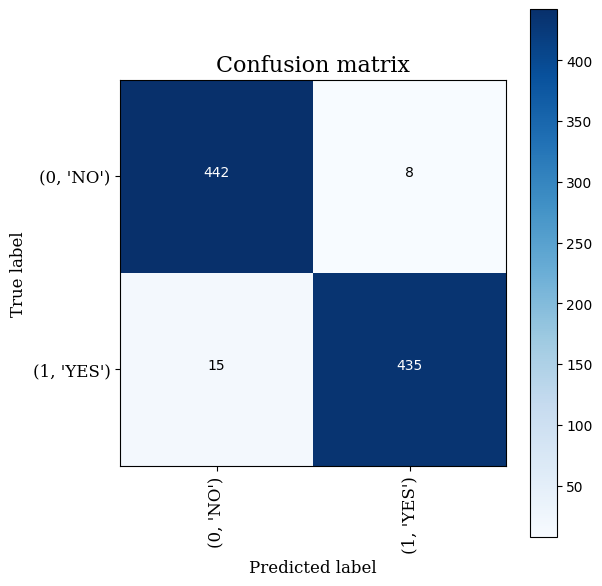

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues,
                          title_font={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 16},
                          text_font={'family': 'serif', 'weight': 'normal', 'size': 12} # Remove 'color' from text_font
                            ):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, **title_font) # Apply title_font using dictionary unpacking
    plt.colorbar()
    tick_marks = np.arange(len(classes))

    # Set x-axis tick labels and apply font properties
    plt.xticks(tick_marks, classes, rotation=90)
    for tick in plt.gca().xaxis.get_major_ticks():
        # Access label through label1 for Matplotlib 3.6+
        tick.label1.set_fontproperties(text_font)
        tick.label1.set_color(title_font['color']) # Set color separately

    # Set y-axis tick labels and apply font properties
    plt.yticks(tick_marks, classes)
    for tick in plt.gca().yaxis.get_major_ticks():
        # Access label through label2 for Matplotlib 3.6+
        tick.label1.set_fontproperties(text_font)
        tick.label1.set_color(title_font['color']) # Set color separately

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()

    # Apply text_font to axis labels using dictionary unpacking
    plt.ylabel('True label', **text_font)  # Use text_font for label properties
    plt.xlabel('Predicted label', **text_font) # Use text_font for label properties
    plt.gca().yaxis.label.set_color(title_font['color']) # Set color for ylabel
    plt.gca().xaxis.label.set_color(title_font['color']) # Set color for xlabel

    plt.show()
confusion_mtx = confusion_matrix(y_test, predictions)
cm = plot_confusion_matrix(confusion_mtx, classes = list(labels.items()), normalize=False)

In [ ]:
# list23 = history.history['accuracy']
# list2 = history.history['val_accuracy']

In [ ]:
# import matplotlib.pyplot as plt
# f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# t = f.suptitle('Basic CNN-PreTrained Model Performance', fontsize=20)
# f.subplots_adjust(top=0.85, wspace=0.3)

# epoch_list = list(range(0,EPOCHS))
# ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
# ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')
# ax1.set_xticks(np.arange(0, EPOCHS, 10))
# ax1.set_ylabel('Accuracy Value')
# ax1.set_xlabel('Epoch')
# ax1.set_title('Accuracy')
# l1 = ax1.legend(loc="best")

# ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
# ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')
# ax2.set_xticks(np.arange(0, 50, 10))
# ax2.set_ylabel('Loss Value')
# ax2.set_xlabel('Epoch')
# ax2.set_title('Loss')
# l2 = ax2.legend(loc="best")

In [ ]:
# import matplotlib.pyplot as plt

# # Example data (replace with your actual training history)
# epochs = range(1, 11)  # Number of epochs
# training_accuracy = [0.5, 0.8, 0.9, 0.95, 0.97, 0.98, 0.99, 0.99, 1.0, 1.0]
# np.arange(0, EPOCHS, 10)
# validation_accuracy = [0.6, 0.75, 0.85, 0.9, 0.92, 0.93, 0.94, 0.94, 0.95, 0.95]

# # Best epoch (index + 1 since epochs start at 1)
# best_epoch = 9
# best_val_accuracy = validation_accuracy[best_epoch - 1]

# # Plot training and validation accuracy
# plt.figure(figsize=(8, 6))
# plt.plot(epochs, training_accuracy, 'r-', label='Training Accuracy')  # Red line
# plt.plot(epochs, validation_accuracy, 'g-', label='Validation Accuracy')  # Green line

# # Highlight the best epoch
# plt.scatter(best_epoch, best_val_accuracy, color='blue', label=f'Best Epoch = {best_epoch}', zorder=5)

# # Add labels, title, and legend
# plt.title('Training and Validation Accuracy', fontsize=14)
# plt.xlabel('Epochs', fontsize=12)
# plt.ylabel('Accuracy', fontsize=12)
# plt.legend()
# plt.grid(True)

# # Show plot
# plt.tight_layout()
# plt.show()


In [ ]:
# get_ipython().magic('reset -sf')